# **Klasifikasi Sampah dengan Transfer Learning (CNN)**

**Final Project Machine Learning**

Notebook ini membangun model *image classification* untuk mengelompokkan foto sampah ke dalam **6 kelas**: Botol Plastik, Kaca, Karton Minuman, Kemasan Logam, Kertas & Karton, dan Sampah Rumah Tangga.

Dataset yang dipakai: [`manonstr/tipe-webscraping`](https://www.kaggle.com/datasets/manonstr/tipe-webscraping) dari Kaggle, total **7.018 gambar** setelah dibersihkan.

**Ringkasan hasil akhir** (lihat detail interpretasi di tiap bagian): baseline CNN dari nol cuma sampai ±75% val accuracy, sedangkan transfer learning MobileNetV2 yang di-fine-tune akhirnya mencapai **98% accuracy** di test set (1.053 gambar) dengan gap train-val cuma 0,3% — jadi modelnya generalisasi dengan baik, bukan menghafal data training.


## 1. Setup & Import Library

Import seluruh library yang dibutuhkan: manipulasi data (`numpy`, `pandas`), visualisasi (`matplotlib`, `seaborn`), pemrosesan gambar (`PIL`), download dataset (`kagglehub`), sampai modeling (`tensorflow`/`keras`) dan evaluasi (`sklearn`). Sekaligus mengecek ketersediaan GPU, karena training CNN jauh lebih cepat dengan GPU.


In [ ]:
# Import seluruh library yang dipakai: data handling, visualisasi, pemrosesan gambar, download dataset, modeling, dan evaluasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random
import os
import kagglehub
import shutil
from google.colab import files

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

sns.set_style("whitegrid")
print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download & Eksplorasi Struktur Dataset

Dataset diunduh langsung dari Kaggle memakai `kagglehub` (ukuran arsip ±1,1 GB), jadi tidak perlu upload manual. Setelah terunduh, struktur foldernya dicek lebih dalam untuk memastikan lokasi data training yang tepat.


In [ ]:
# Unduh dataset terbaru dari Kaggle via kagglehub (otomatis ter-cache lokal, ukuran arsip ±1,1 GB)
DATA_ROOT = kagglehub.dataset_download("manonstr/tipe-webscraping")
print("Dataset berhasil didownload ke:", DATA_ROOT)

100%|██████████| 1.12G/1.12G [00:11<00:00, 105MB/s]

Extracting files...


Dataset berhasil didownload ke: /root/.cache/kagglehub/datasets/manonstr/tipe-webscraping/versions/12


In [ ]:
print("Isi folder hasil download:")
for item in os.listdir(DATA_ROOT):
    print(" -", item)

Isi folder hasil download:
 - 1024+


In [ ]:
# Fungsi rekursif untuk menampilkan struktur folder dataset sampai kedalaman tertentu (biar ketahuan lokasi data training & test)
def explore_structure(path, max_depth=3, current_depth=0, prefix=""):
    if current_depth > max_depth:
        return
    try:
        items = sorted(os.listdir(path))
    except NotADirectoryError:
        return

    dirs = [i for i in items if os.path.isdir(os.path.join(path, i))]
    files_here = [i for i in items if os.path.isfile(os.path.join(path, i))]

    if files_here:
        print(f"{prefix}📄 {len(files_here)} file (contoh: {files_here[0]})")

    for d in dirs:
        print(f"{prefix}📁 {d}/")
        explore_structure(os.path.join(path, d), max_depth, current_depth + 1, prefix + "  ")

print("Struktur folder dataset:\n")
explore_structure(DATA_ROOT)

Struktur folder dataset:

📁 1024+/
  📁 entrainement/
    📁 Bouteille_plastique/
      📄 1439 file (contoh: bouteille_plastique_1.jpg)
    📁 Brique_en_carton/
      📄 1049 file (contoh: Brique_en_carton_1.jpg)
    📁 Emballage_metallique/
      📄 1217 file (contoh: metal_1.jpg)
    📁 Ordure_m∩┐╜nag∩┐╜re/
      📄 1050 file (contoh: Ordure_menagere_1.jpg)
    📁 Papier_Carton/
      📄 1046 file (contoh: Papier_carton_1.jpg)
    📁 Verre/
      📄 1232 file (contoh: papier_carton_1.jpg)
  📁 test/
    📁 Bouteille_plastique/
      📄 35 file (contoh: Bouteille_plastique_1.jpg)
    📁 Brique_en_carton/
      📄 15 file (contoh: Brique_en_carton_1.jpg)
    📁 Emballage_metallique/
      📄 25 file (contoh: Emballage_metallique_1.jpg)
    📁 Ordure_m∩┐╜nag∩┐╜re/
      📄 10 file (contoh: Ordure_menagere_1.jpg)
    📁 Papier_Carton/
      📄 44 file (contoh: Papier_carton_1.jpg)
    📁 Verre/
      📄 28 file (contoh: Verre_1.jpg)


## 3. Deteksi Kelas & Pembersihan Nama Folder

Dataset aslinya memakai nama folder berbahasa Prancis (`Bouteille_plastique`, `Verre`, dst). Dari hasil deteksi, ada 6 folder kelas, dan salah satunya (`Ordure_ménagère`) namanya rusak jadi `Ordure_m∩┐╜nag∩┐╜re` karena masalah encoding karakter saat dibaca `os.listdir`. Karena itu nama-nama folder ini perlu dipetakan ulang ke bahasa Indonesia yang lebih mudah dibaca dan konsisten.


In [ ]:
# Deteksi kelas dari nama folder training (masih pakai nama asli berbahasa Prancis, akan di-mapping ke Indonesia di langkah berikutnya)
TRAIN_SOURCE_DIR = os.path.join(DATA_ROOT, "1024+", "entrainement")
ORIGINAL_TEST_DIR = os.path.join(DATA_ROOT, "1024+", "test")  # dipakai lagi nanti di bagian sanity-check tambahan (section 9)

DATA_DIR = TRAIN_SOURCE_DIR

class_names = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
print(f"Kelas terdeteksi ({len(class_names)}):")
for c in class_names:
    print(" -", c)

Kelas terdeteksi (6):
 - Bouteille_plastique
 - Brique_en_carton
 - Emballage_metallique
 - Ordure_m∩┐╜nag∩┐╜re
 - Papier_Carton
 - Verre


In [ ]:
# Intip nama file tiap kelas untuk sanity check penamaan (dari sini ketahuan folder Verre isinya file bernama papier_carton_...)
print("Contoh nama file per kelas :\n")
for cls in class_names:
    cls_path = os.path.join(DATA_DIR, cls)
    sample_files = os.listdir(cls_path)[:3]
    print(f"{cls}:")
    for f in sample_files:
        print(f"   - {f}")

Contoh nama file per kelas :

Bouteille_plastique:
   - bouteille_plastique_1429.jpg
   - bouteille_plastique_1360.jpg
   - bouteille_plastique_1053.jpg
Brique_en_carton:
   - Brique_en_carton_161.jpg
   - Brique_en_carton_639.jpg
   - Brique_en_carton_508.jpg
Emballage_metallique:
   - metal_179.jpg
   - metal_271.jpg
   - metal_527.jpg
Ordure_m∩┐╜nag∩┐╜re:
   - Ordure_menagere_62.jpg
   - Ordure_menagere_266.jpeg
   - Ordure_menagere_745.jpg
Papier_Carton:
   - Papier_carton_144.jpg
   - Papier_carton_331.jpg
   - Papier_carton_806.jpg
Verre:
   - papier_carton_180.jpg
   - papier_carton_37.jpg
   - papier_carton_39.jpg


Ada temuan menarik saat mengecek nama file tiap kelas: folder `Verre` (kaca) ternyata isinya file-file dengan nama `papier_carton_...jpg` — kemungkinan salah label/penamaan dari sumber dataset aslinya, tapi karena posisinya sudah benar di dalam folder `Verre`, datanya tetap dipakai apa adanya (asumsi: isi foto memang kaca, cuma nama filenya yang keliru).

Supaya lebih mudah dibaca dan konsisten, nama kelas di-mapping ke Bahasa Indonesia. Folder disalin memakai *symlink* (bukan copy fisik) ke folder baru `data_clean`, agar hemat waktu & storage. Seluruh tahap berikutnya mengacu ke folder ini. Hasilnya, 5 kelas berhasil dipetakan lewat dictionary (`Botol_Plastik`, `Karton_Minuman`, `Kemasan_Logam`, `Kaca`, `Kertas_Karton`), dan folder yang namanya rusak tadi otomatis jatuh ke fallback `Sampah_Rumah_Tangga` — sesuai dugaan awal.


In [ ]:
# Mapping nama folder asli (Prancis) ke bahasa Indonesia, disalin via symlink (bukan copy fisik) ke folder baru
CLEAN_DIR = "/content/data_clean"
os.makedirs(CLEAN_DIR, exist_ok=True)

# Dictionary mapping untuk 5 kelas yang nama aslinya jelas & tidak korup
class_name_mapping = {
    "Bouteille_plastique": "Botol_Plastik",
    "Brique_en_carton": "Karton_Minuman",
    "Emballage_metallique": "Kemasan_Logam",
    "Papier_Carton": "Kertas_Karton",
    "Verre": "Kaca",
}
# folder 'Ordure_ménagère' namanya rusak jadi 'Ordure_m∩┐╜nag∩┐╜re' karena masalah encoding, otomatis tidak match dictionary -> jatuh ke fallback 'Sampah_Rumah_Tangga'
for original_name in os.listdir(DATA_DIR):
    src = os.path.join(DATA_DIR, original_name)
    if not os.path.isdir(src):
        continue

    clean_name = class_name_mapping.get(original_name, "Sampah_Rumah_Tangga")

    dst = os.path.join(CLEAN_DIR, clean_name)
    if not os.path.exists(dst):
        os.symlink(src, dst)
    print(f"{original_name}  =  {clean_name}")

# Pakai folder yg sudah diubah ini untuk seluruh tahap selanjutnya
DATA_DIR = CLEAN_DIR
class_names = sorted(os.listdir(DATA_DIR))
print("\n Kelas dengan nama baru:", class_names)

Ordure_m∩┐╜nag∩┐╜re  =  Sampah_Rumah_Tangga
Bouteille_plastique  =  Botol_Plastik
Papier_Carton  =  Kertas_Karton
Emballage_metallique  =  Kemasan_Logam
Verre  =  Kaca
Brique_en_carton  =  Karton_Minuman

 Kelas dengan nama baru: ['Botol_Plastik', 'Kaca', 'Karton_Minuman', 'Kemasan_Logam', 'Kertas_Karton', 'Sampah_Rumah_Tangga']


In [ ]:
# Simpan jumlah kelas (hasil: 6) untuk dipakai membangun output layer model nanti
NUM_CLASSES = len(class_names)
print(f"Jumlah kelas: {NUM_CLASSES}")

Jumlah kelas: 6


## 4. Exploratory Data Analysis (EDA)

- Melihat berapa banyak gambar per kelas (cek *class imbalance* dan volume total data)
- Melihat contoh gambar tiap kelas
- Mengecek variasi ukuran/resolusi gambar


###**a. Distribusi jumlah gambar per kelas**

In [ ]:
# Hitung jumlah file gambar valid (jpg/jpeg/png/webp) di tiap folder kelas
class_counts = {}

for cls in class_names:
    cls_path = os.path.join(DATA_DIR, cls)
    n_images = len([f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))])
    class_counts[cls] = n_images

df_counts = pd.DataFrame(list(class_counts.items()), columns=["kelas", "jumlah_gambar"])
df_counts = df_counts.sort_values("jumlah_gambar", ascending=False).reset_index(drop=True)

total_images = df_counts["jumlah_gambar"].sum()
print(f"Total kelas: {len(df_counts)}")
print(f"Total gambar: {total_images}")
df_counts

Total kelas: 6
Total gambar: 7018


,kelas,jumlah_gambar
0,Botol_Plastik,1437
1,Kaca,1225
2,Kemasan_Logam,1217
3,Sampah_Rumah_Tangga,1050
4,Karton_Minuman,1047
5,Kertas_Karton,1042


Dari tabel di atas, total ada **7.018 gambar** tersebar di 6 kelas, dengan jumlah per kelas berkisar 1.042–1.437 gambar. Sekilas terlihat cukup merata, tapi biar lebih jelas seberapa timpang selisihnya, divisualisasikan dulu di bawah.

###**b. Visualisasi distribusi kelas**

/tmp/ipykernel_2090/491397802.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x="jumlah_gambar", y="kelas", palette="viridis")


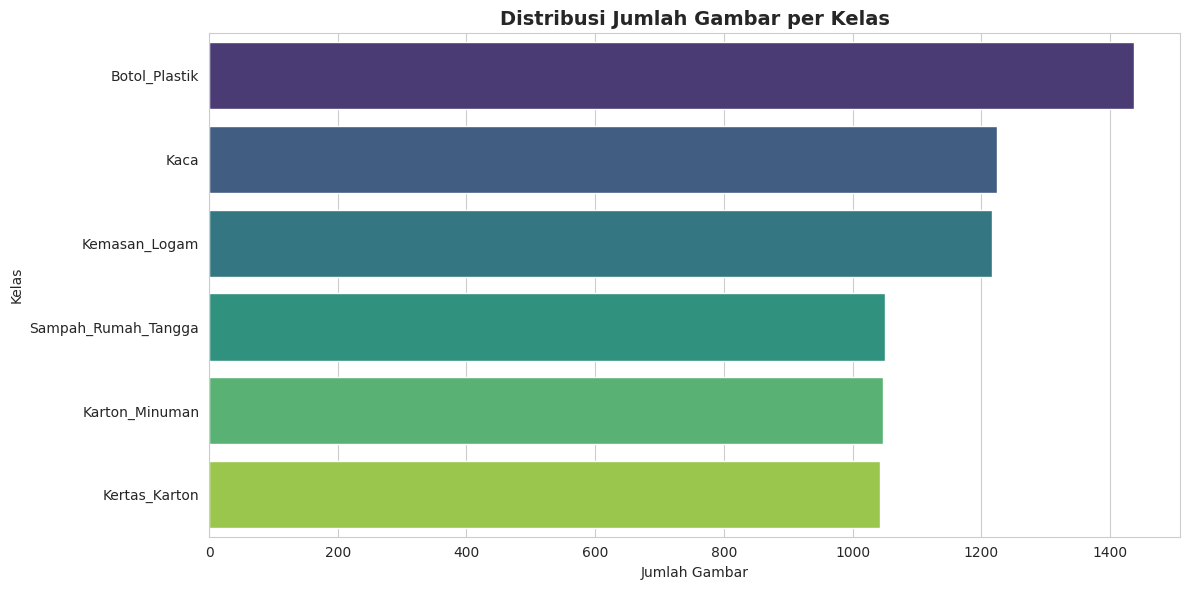


 Kelas terbanyak : Botol_Plastik (1437 gambar)
 Kelas tersedikit: Kertas_Karton (1042 gambar)
 Rasio imbalance : 1.4x


In [ ]:
# Visualisasi distribusi jumlah gambar per kelas + hitung rasio imbalance kelas terbanyak vs tersedikit
plt.figure(figsize=(12, 6))
sns.barplot(data=df_counts, x="jumlah_gambar", y="kelas", palette="viridis")
plt.title("Distribusi Jumlah Gambar per Kelas", fontsize=14, fontweight="bold")
plt.xlabel("Jumlah Gambar")
plt.ylabel("Kelas")
plt.tight_layout()
plt.show()

max_cls = df_counts.iloc[0]
min_cls = df_counts.iloc[-1]
ratio = max_cls["jumlah_gambar"] / max(min_cls["jumlah_gambar"], 1)
print(f"\n Kelas terbanyak : {max_cls['kelas']} ({max_cls['jumlah_gambar']} gambar)")
print(f" Kelas tersedikit: {min_cls['kelas']} ({min_cls['jumlah_gambar']} gambar)")
print(f" Rasio imbalance : {ratio:.1f}x")
if ratio > 3:
    print(" Ada indikasi class imbalance signifikan.")

Dari visualisasi barplot-nya, `Botol_Plastik` adalah kelas terbanyak (1.437 gambar) dan `Kertas_Karton` paling sedikit (1.042 gambar), dengan rasio imbalance cuma **1,4x**. Ini tergolong ringan (bukan rasio ekstrem seperti 10x atau lebih), jadi tidak perlu teknik balancing berat seperti oversampling — stratified split saja cukup untuk menjaga proporsi kelas.

###**c. Contoh gambar dari tiap kelas**

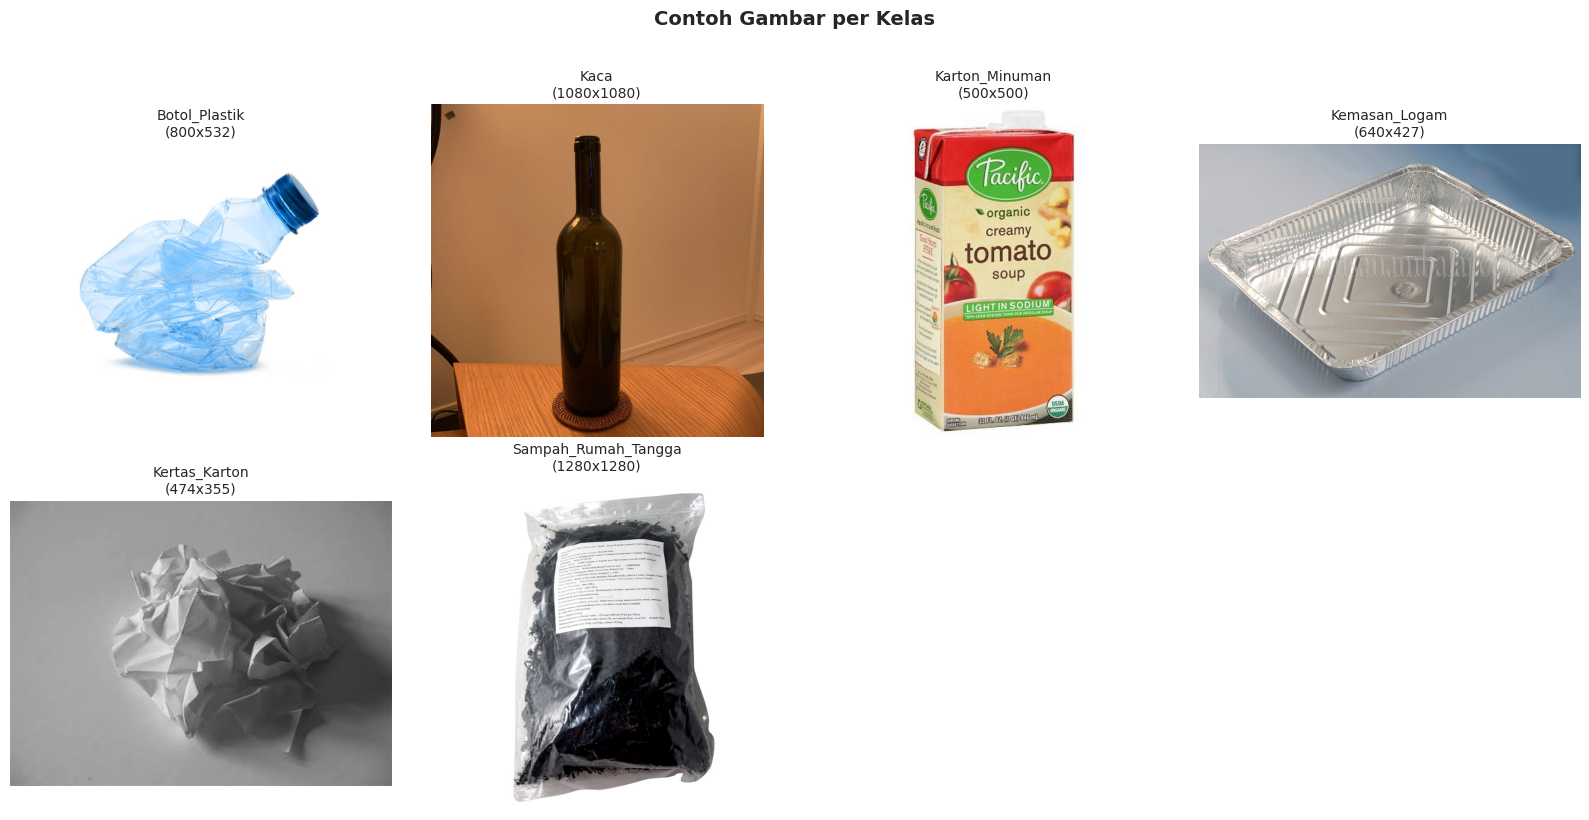

In [ ]:
# Ambil 1 gambar random dari tiap kelas (maks 12 kelas ditampilkan) untuk sanity check visual
n_classes_to_show = min(12, len(class_names))
n_cols = 4
n_rows = (n_classes_to_show + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten() if n_classes_to_show > 1 else [axes]

for i, cls in enumerate(class_names[:n_classes_to_show]):
    cls_path = os.path.join(DATA_DIR, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
    if images:
        sample_img = random.choice(images)
        img = Image.open(os.path.join(cls_path, sample_img))
        axes[i].imshow(img)
        axes[i].set_title(f"{cls}\n({img.size[0]}x{img.size[1]})", fontsize=10)
        axes[i].axis("off")

# Sembunyikan axes kosong kalau jumlah kelas tidak pas grid
for j in range(n_classes_to_show, len(axes)):
    axes[j].axis("off")

plt.suptitle("Contoh Gambar per Kelas", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

###**d. Variasi ukuran/resolusi dari gambar**

In [ ]:
# Cek variasi ukuran/resolusi gambar, ambil sample 20 gambar per kelas biar tidak perlu buka semua 7000+ file
sample_sizes = []
for cls in class_names:
    cls_path = os.path.join(DATA_DIR, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
    sample = random.sample(images, min(20, len(images)))
    for img_name in sample:
        try:
            with Image.open(os.path.join(cls_path, img_name)) as img:
                sample_sizes.append(img.size)
        except Exception as e:
            print(f"Gagal buka {img_name}: {e}")

if sample_sizes:
    widths = [s[0] for s in sample_sizes]
    heights = [s[1] for s in sample_sizes]
    print(f"Lebar gambar  -> min: {min(widths)}, max: {max(widths)}, rata-rata: {np.mean(widths):.0f}")
    print(f"Tinggi gambar -> min: {min(heights)}, max: {max(heights)}, rata-rata: {np.mean(heights):.0f}")
    print("\n Karena resolusi bervariasi, semua gambar perlu di-resize ke ukuran seragam saat preprocessing.")

Lebar gambar  -> min: 83, max: 2250, rata-rata: 585
Tinggi gambar -> min: 146, max: 4032, rata-rata: 615

 Karena resolusi bervariasi, semua gambar perlu di-resize ke ukuran seragam saat preprocessing.


## Insight Hasil Exploratory Data Analysis

Dari hasil EDA di atas, berikut beberapa hal penting yang ditemukan pada dataset klasifikasi sampah ini:

1. **Distribusi Data.** Total 7.018 gambar tersebar di 6 kelas, dari yang terbanyak `Botol_Plastik` (1.437) sampai yang tersedikit `Kertas_Karton` (1.042) — rasio imbalance cuma 1,4x. Karena tergolong ringan, tidak perlu balancing berlebihan, cukup pakai stratified split agar proporsi tiap kelas tetap terjaga di data train, validation, dan test.

2. **Ukuran Gambar.** Resolusinya sangat beragam: lebar berkisar 83–2.250 px (rata-rata 585 px) dan tinggi 146–4.032 px (rata-rata 615 px). Karena rentangnya jauh (dari gambar kecil sampai hampir 4K), semua gambar perlu diseragamkan ukurannya — dipilih 224×224 piksel, ukuran standar untuk arsitektur transfer learning seperti MobileNetV2/ResNet50/EfficientNet.

3. **Penamaan Data yang Tidak Konsisten.** Ditemukan 2 anomali sekaligus: folder `Ordure_ménagère` namanya rusak karena encoding, dan folder `Verre` (kaca) isinya file-file bernama `papier_carton_...`. Keduanya sudah ditangani lewat mapping manual + fallback, tapi ini jadi pengingat kalau dataset scraping perlu dicek detail sebelum dipakai mentah-mentah.

4. **Data Augmentation.** Karena kondisi gambar cukup beragam (resolusi, kemungkinan sudut pengambilan), augmentasi seperti rotation, flip, perubahan brightness, dan zoom/shear dipakai supaya model tetap bisa mengenali sampah meskipun posisi dan kondisi gambarnya berbeda-beda.

5. **Strategi Model.** Dengan total 7.018 gambar (tergolong menengah, bukan dataset raksasa), transfer learning jadi pilihan yang masuk akal dibanding training CNN dari nol. Tiga arsitektur pretrained (MobileNetV2, ResNet50, EfficientNetB0) dicoba lalu dibandingkan performanya.

**Kesimpulan:** Dataset ini sudah cukup layak dipakai setelah pembersihan nama folder. Fokus utama tahap berikutnya adalah menyamakan ukuran gambar, augmentasi, menjaga proporsi kelas lewat stratified split, lalu membandingkan beberapa arsitektur transfer learning untuk cari performa terbaik.


## 5. Preprocessing & Split Data
- Resize semua gambar ke ukuran seragam (224x224 — standar untuk transfer learning)
- Split data menjadi train / validation / test dengan stratifikasi (proporsi kelas tetap terjaga)
- Siapkan data augmentation untuk training set (penting kalau volume data kecil)


###**a. Mengumpulkan filepath & label setiap gambar ke dalam satu dataframe**

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

filepaths = []
labels = []

for cls in class_names:
    cls_path = os.path.join(DATA_DIR, cls)
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
            filepaths.append(os.path.join(cls_path, fname))
            labels.append(cls)

df_all = pd.DataFrame({"filepath": filepaths, "label": labels})
print(f"Total data: {len(df_all)}")
df_all.head()

Total data: 7018


,filepath,label
0,/content/data_clean/Botol_Plastik/bouteille_pl...,Botol_Plastik
1,/content/data_clean/Botol_Plastik/bouteille_pl...,Botol_Plastik
2,/content/data_clean/Botol_Plastik/bouteille_pl...,Botol_Plastik
3,/content/data_clean/Botol_Plastik/bouteille_pl...,Botol_Plastik
4,/content/data_clean/Botol_Plastik/bouteille_pl...,Botol_Plastik


###**b. Validasi jumlah minimum data per kelas**

Karena kelas paling sedikit saja sudah punya 1.042 gambar (jauh di atas syarat minimum 2 sample untuk stratified split), validasi ini dipastikan otomatis lolos — cuma langkah jaga-jaga sebelum split.

In [ ]:
# Validasi tiap kelas punya minimal 2 sample untuk stratified split (kelas tersedikit di sini ada 1.042 gambar, jadi harusnya aman)
label_counts = df_all["label"].value_counts()
too_small = label_counts[label_counts < 2]
if len(too_small) > 0:
    print("Kelas berikut punya <2 gambar, tidak bisa di-stratify:")
    print(too_small)
    print("Pertimbangkan menggabungkan atau membuang kelas ini.")
else:
    print("Semua kelas punya cukup data untuk stratified split.")

Semua kelas punya cukup data untuk stratified split.


###**c. Split data jadi train/valid/test**

In [ ]:
# Split stratified: 70% train, 15% validation, 15% test (proporsi kelas dijaga tetap sama di tiap subset)
train_df, temp_df = train_test_split(
    df_all, test_size=0.30, stratify=df_all["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

print(f"Train : {len(train_df)} gambar")
print(f"Val   : {len(val_df)} gambar")
print(f"Test  : {len(test_df)} gambar")

print("\nProporsi kelas (train):")
print(train_df["label"].value_counts(normalize=True).round(3))

Train : 4912 gambar
Val   : 1053 gambar
Test  : 1053 gambar

Proporsi kelas (train):
label
Botol_Plastik          0.205
Kaca                   0.174
Kemasan_Logam          0.173
Sampah_Rumah_Tangga    0.150
Karton_Minuman         0.149
Kertas_Karton          0.148
Name: proportion, dtype: float64


Hasil split: **4.912 gambar** untuk train, **1.053** untuk validation, dan **1.053** untuk test (rasio 70/15/15). Proporsi tiap kelas di data train (20,5% `Botol_Plastik` sampai 14,8% `Kertas_Karton`) sudah sesuai dengan proporsi aslinya di seluruh dataset — konfirmasi kalau stratified split berhasil menjaga distribusi kelas.

###**d. Buat data generator dengan augmentasi**

In [ ]:
# Data augmentation untuk training set saja (val/test cuma di-rescale, tanpa augmentasi, biar evaluasinya representatif)
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
)

val_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED,
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

print("Generator siap. Class indices:")
print(train_generator.class_indices)

Found 4912 validated image filenames belonging to 6 classes.
Found 1053 validated image filenames belonging to 6 classes.
Found 1053 validated image filenames belonging to 6 classes.
Generator siap. Class indices:
{'Botol_Plastik': 0, 'Kaca': 1, 'Karton_Minuman': 2, 'Kemasan_Logam': 3, 'Kertas_Karton': 4, 'Sampah_Rumah_Tangga': 5}


###**e. Melihat hasil dari Augmentasi**

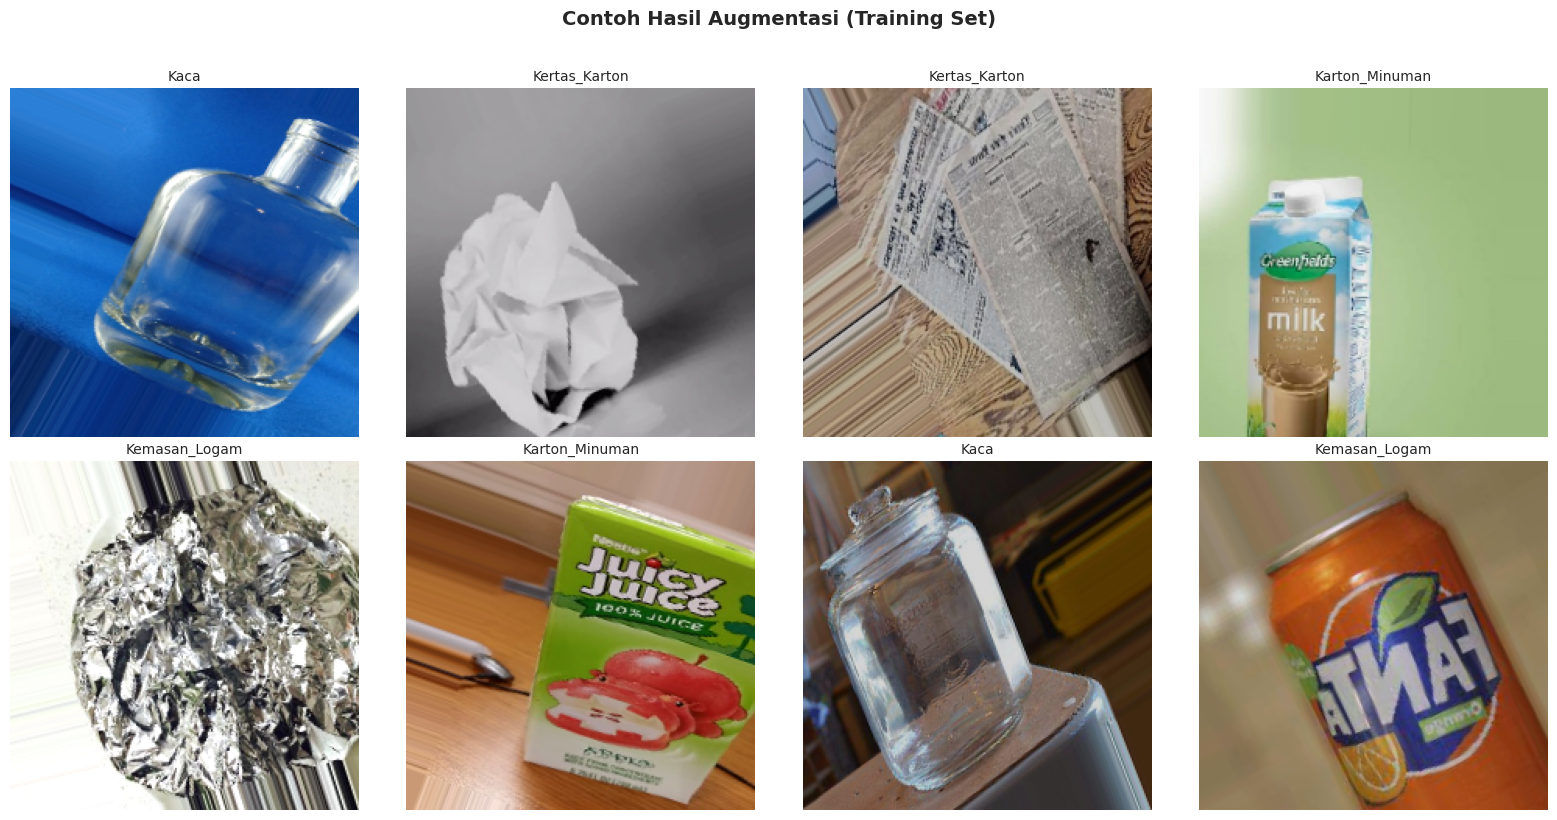

In [ ]:
# Preview hasil augmentasi pada 1 batch gambar training, buat sanity check apakah augmentasinya wajar (tidak merusak objek)
sample_batch, sample_labels = next(train_generator)

n_preview = min(8, len(sample_batch))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
class_list = list(train_generator.class_indices.keys())

for i in range(n_preview):
    axes[i].imshow(sample_batch[i])
    label_idx = np.argmax(sample_labels[i])
    axes[i].set_title(class_list[label_idx], fontsize=10)
    axes[i].axis("off")
for j in range(n_preview, len(axes)):
    axes[j].axis("off")

plt.suptitle("Contoh Hasil Augmentasi (Training Set)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6. Model Baseline: CNN Sederhana

Tujuan baseline supaya punya angka pembanding sebelum coba model yang lebih canggih (transfer learning). CNN sederhana ini dilatih dari nol (bobot random), tanpa memanfaatkan pretrained weight sama sekali.


In [ ]:
def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=NUM_CLASSES):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=input_shape),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])
    return model

baseline_model = build_baseline_cnn()
baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
baseline_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Melatih model baseline dari nol selama 10 epoch, tanpa pretrained weight
EPOCHS_BASELINE = 10

baseline_history = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_BASELINE,
)

Epoch 1/10
 10/154 ━━━━━━━━━━━━━━━━━━━━ 2:02 849ms/step - accuracy: 0.1567 - loss: 2.6679

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


154/154 ━━━━━━━━━━━━━━━━━━━━ 121s 728ms/step - accuracy: 0.2985 - loss: 1.6818 - val_accuracy: 0.3675 - val_loss: 1.5397
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 96s 623ms/step - accuracy: 0.4438 - loss: 1.4273 - val_accuracy: 0.5480 - val_loss: 1.2122
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 98s 631ms/step - accuracy: 0.4754 - loss: 1.3308 - val_accuracy: 0.6220 - val_loss: 1.0449
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 96s 623ms/step - accuracy: 0.5263 - loss: 1.2380 - val_accuracy: 0.6553 - val_loss: 0.9892
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 95s 619ms/step - accuracy: 0.5548 - loss: 1.1872 - val_accuracy: 0.5850 - val_loss: 1.0290
Epoch 6/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 96s 619ms/step - accuracy: 0.5678 - loss: 1.1371 - val_accuracy: 0.6952 - val_loss: 0.8579
Epoch 7/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 96s 625ms/step - accuracy: 0.5939 - loss: 1.0865 - val_accuracy: 0.7236 - val_loss: 0.8149
Epoch 8/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 95s 617ms/step - accuracy: 0.6148 - loss: 1.0244 - va

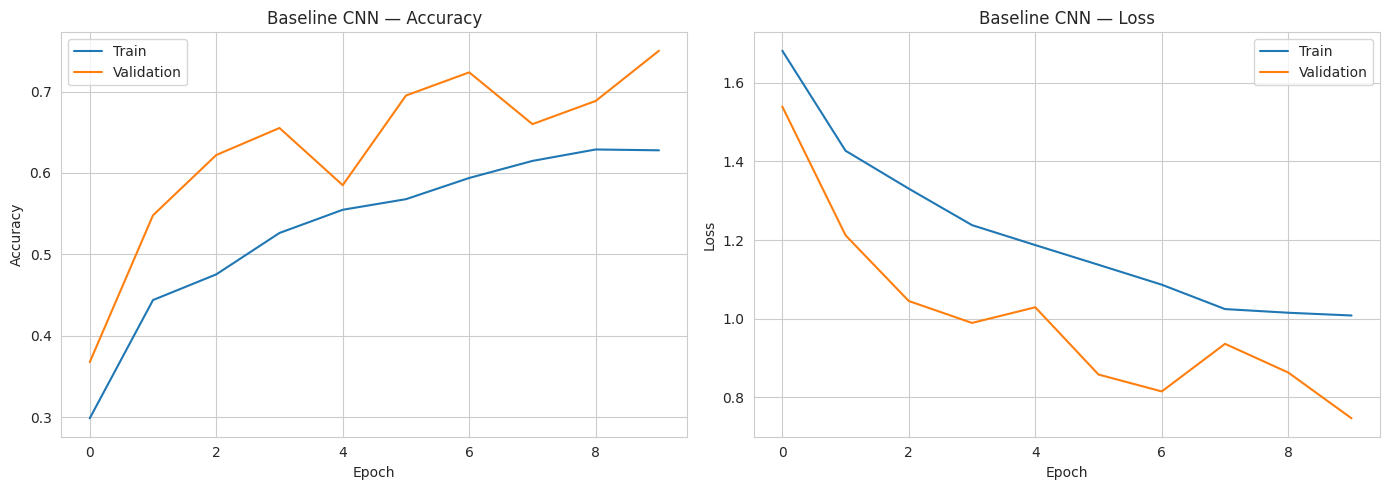

Best validation accuracy (baseline): 0.7502


In [ ]:
# Plot learning curve accuracy & loss, plus ambil best validation accuracy sebagai angka pembanding baseline
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(baseline_history.history["accuracy"], label="Train")
axes[0].plot(baseline_history.history["val_accuracy"], label="Validation")
axes[0].set_title("Baseline CNN — Accuracy")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(baseline_history.history["loss"], label="Train")
axes[1].plot(baseline_history.history["val_loss"], label="Validation")
axes[1].set_title("Baseline CNN — Loss")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout()
plt.show()

baseline_val_acc = max(baseline_history.history["val_accuracy"])
print(f"Best validation accuracy (baseline): {baseline_val_acc:.4f}")

Baseline CNN mencapai *validation accuracy* terbaik sekitar **75,02%** (di epoch ke-10). Menariknya, di epoch terakhir train accuracy (62,79%) justru lebih rendah dari val accuracy (75,02%) — ini wajar terjadi karena augmentasi + dropout cuma aktif saat training, jadi metrik train "dibuat lebih sulit" dibanding val. Val accuracy-nya juga naik-turun antar epoch (tidak mulus), tanda training dari nol pada data yang relatif terbatas ini belum stabil. Angka 75,02% ini jadi pembanding: kalau transfer learning tidak mengalahkan ini, berarti transfer learning-nya belum optimal.


##  7. Transfer Learning & Perbandingan Model

Mencoba 3 arsitektur pretrained (dilatih di ImageNet) sebagai feature extractor:
- **MobileNetV2** — ringan & cepat, cocok untuk deployment
- **ResNet50** — cukup dalam, akurasi biasanya solid
- **EfficientNetB0** — efisien, akurasi tinggi dengan parameter lebih sedikit

Base layer di-freeze dulu (tidak dilatih ulang), cuma classifier head di atasnya yang dilatih supaya training jauh lebih cepat dan tidak butuh data sebanyak training dari nol.


In [ ]:
# Mapping fungsi preprocessing resmi untuk tiap arsitektur
preprocess_map = {
    "MobileNetV2": tf.keras.applications.mobilenet_v2.preprocess_input,
    "ResNet50": tf.keras.applications.resnet50.preprocess_input,
    "EfficientNetB0": tf.keras.applications.efficientnet.preprocess_input,
}

def build_transfer_model(base_model_fn, model_name, input_shape=(224, 224, 3), num_classes=NUM_CLASSES):
    base_model = base_model_fn(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False  # freeze base layers

    inputs = tf.keras.Input(shape=input_shape)

    # Generator sudah rescale ke [0,1] -> kembalikan dulu ke [0,255]
    x = tf.keras.layers.Rescaling(255.0)(inputs)
    # terapkan preprocessing sesuai arsitektur (MobileNetV2/ResNet50/EfficientNetB0)
    x = tf.keras.layers.Lambda(preprocess_map[model_name], name="architecture_preprocessing")(x)

    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name=model_name)
    return model, base_model

model_configs = {
    "MobileNetV2": tf.keras.applications.MobileNetV2,
    "ResNet50": tf.keras.applications.ResNet50,
    "EfficientNetB0": tf.keras.applications.EfficientNetB0,
}

print("Model yang akan dibandingkan:", list(model_configs.keys()))

Model yang akan dibandingkan: ['MobileNetV2', 'ResNet50', 'EfficientNetB0']


Melatih ketiga model transfer learning secara bergantian selama maksimal 8 epoch, masing-masing dengan *early stopping* (berhenti otomatis kalau val_loss tidak membaik selama 3 epoch berturut-turut) supaya tidak overfitting dan hemat waktu.

In [ ]:
EPOCHS_TRANSFER = 8
results = {}  # simpan history & val_acc tiap model
trained_models = {}  # simpan model object untuk evaluasi
base_models = {}  # simpan base_model object untuk fine-tuning

for name, base_fn in model_configs.items():
    print(f"\n{'~'*50}\n Training {name}\n{'~'*50}")

    model, base_model = build_transfer_model(base_fn, name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    )

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS_TRANSFER,
        callbacks=[early_stop],
    )

    results[name] = history.history
    trained_models[name] = model
    base_models[name] = base_model

    best_val_acc = max(history.history["val_accuracy"])
    print(f"{name} — Best val_accuracy: {best_val_acc:.4f}")


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Training MobileNetV2
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
154/154 ━━━━━━━━━━━━━━━━━━━━ 139s 787ms/step - accuracy: 0.7985 - loss: 0.5862 - val_accuracy: 0.9392 - val_loss: 0.2012
Epoch 2/8
154/154 ━━━━━━━━━━━━━━━━━━━━ 93s 604ms/step - accuracy: 0.9228 - loss: 0.2405 - val_accuracy: 0.9601 - val_loss: 0.1487
Epoch 3/8
154/154 ━━━━━━━━━━━━━━━━━━━━ 94s 608ms/step - accuracy: 0.9355 - loss: 0.1911 - val_accuracy: 0.9649 - val_loss: 0.1237
Epoch 4/8
154/154 ━━━━━━━━━━━━━━━━━━━━ 94s 610ms/step - accuracy: 0.9465 - loss: 0.1593 - val_accuracy: 0.9677 - val_loss: 0.1255
Epoch 5/8
154/154 ━━━━━━━━━━━━━━━━━━━━ 93s 606ms/step - accuracy: 0.9481 - loss: 0.1474 - val_accuracy: 0.9725 - val_loss: 0.1093
Epoch 6/8
154/154 ━━━━━━━━━━━━━━━━━━━━ 94s 612ms/step - accuracy: 0.9546 - loss: 0.1383 - val_accuracy: 0.9734 - val_loss: 0.1046
Epoch 7/8
154/154 ━━━━━━━━━━━━━━━━━━━━ 94s 60

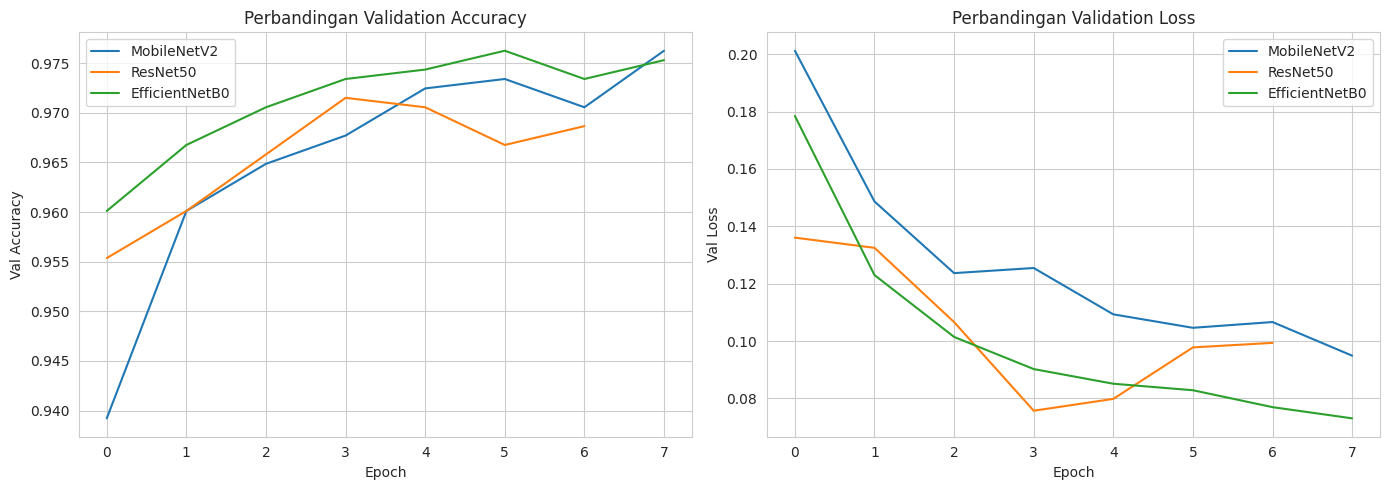

            Model  Best Val Accuracy  Best Val Loss  Baseline CNN Val Accuracy
0     MobileNetV2           0.976258       0.094886                   0.750237
1  EfficientNetB0           0.976258       0.073029                   0.750237
2        ResNet50           0.971510       0.075684                   0.750237


In [ ]:
# Bandingkan performa ketiga model transfer learning terhadap baseline, sekaligus urutkan berdasar val accuracy tertinggi untuk pilih model terbaik
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, hist in results.items():
    axes[0].plot(hist["val_accuracy"], label=name)
    axes[1].plot(hist["val_loss"], label=name)

axes[0].set_title("Perbandingan Validation Accuracy")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val Accuracy"); axes[0].legend()

axes[1].set_title("Perbandingan Validation Loss")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Loss"); axes[1].legend()

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Best Val Accuracy": [max(h["val_accuracy"]) for h in results.values()],
    "Best Val Loss": [min(h["val_loss"]) for h in results.values()],
    "Baseline CNN Val Accuracy": [baseline_val_acc] * len(results),
})
summary_df = summary_df.sort_values("Best Val Accuracy", ascending=False).reset_index(drop=True)
print(summary_df)

**Hasil perbandingan (val accuracy & val loss terbaik):**

| Model | Val Accuracy | Val Loss |
|---|---|---|
| MobileNetV2 | 97,63% | 0,0949 |
| EfficientNetB0 | 97,63% | 0,0730 |
| ResNet50 | 97,15% | 0,0757 |
| Baseline CNN | 75,02% | — |

Ketiga model transfer learning jauh mengungguli baseline CNN (naik lebih dari 22 poin persentase), sesuai ekspektasi. Yang menarik: **MobileNetV2 dan EfficientNetB0 seri persis** di angka val accuracy (97,63%). Karena `summary_df` di-sort cuma berdasarkan accuracy, tie-breaker-nya jatuh ke urutan default hasil sorting pandas, dan yang akhirnya terpilih sebagai "model terbaik" untuk fine-tuning adalah **MobileNetV2** — padahal kalau dilihat dari val loss, EfficientNetB0 sebenarnya sedikit lebih baik/stabil (0,073 vs 0,095). Jadi pemilihan model di sini agak dipengaruhi kebetulan tie-breaking, bukan murni karena MobileNetV2 objektif lebih unggul dari EfficientNetB0.


## 8. Hyperparameter Tuning (Fine-Tuning)

Ambil model **MobileNetV2** (terpilih dari tahap sebelumnya), lalu:
- Unfreeze beberapa layer terakhir dari base model (fine-tuning)
- Eksperimen learning rate lebih kecil (karena fine-tuning butuh update halus)
- Gunakan callback `ReduceLROnPlateau` agar learning rate turun otomatis kalau val_loss stagnan


In [ ]:
BEST_MODEL_NAME = summary_df.iloc[0]["Model"]
print(f"Model terbaik yang akan di-fine-tune: {BEST_MODEL_NAME}")

best_model = trained_models[BEST_MODEL_NAME]

# Ambil base_model dari dictionary (bukan dari trained_models langsung) karena ada layer preprocessing tambahan sebelum base model di dalam Functional API-nya
base_layer = base_models[BEST_MODEL_NAME]
base_layer.trainable = True

fine_tune_at = len(base_layer.layers) - 20
for layer in base_layer.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Total layer di base model: {len(base_layer.layers)}")
print(f"Layer yang di-fine-tune: {len(base_layer.layers) - fine_tune_at}")

Model terbaik yang akan di-fine-tune: MobileNetV2
Total layer di base model: 154
Layer yang di-fine-tune: 20


MobileNetV2 punya total **154 layer** di base model-nya, dan **20 layer terakhir** (±13% dari total) di-unfreeze untuk fine-tuning. Dicoba dua learning rate kecil (`1e-4` dan `1e-5`) — LR yang terlalu besar berisiko merusak bobot pretrained yang sudah bagus. Model dengan val accuracy terbaik di antara kedua percobaan disimpan sebagai `final_model`.


In [ ]:
learning_rates_to_try = [1e-4, 1e-5]
tuning_results = {}
final_model = None  # Inisialisasi final_model untuk menyimpan model hasil fine-tuning terbaik

# Mengambil konfigurasi model terbaik dan bobot lamanya (setelah transfer learning)
BEST_MODEL_NAME = summary_df.iloc[0]["Model"]
base_fn_for_best_model = model_configs[BEST_MODEL_NAME]
initial_best_model_weights = trained_models[BEST_MODEL_NAME].get_weights()

# Mengambil instance base_layer asli untuk menentukan `fine_tune_at` secara konsisten.
# Instance `base_model` di dalam `tuned_model'
base_layer_original = base_models[BEST_MODEL_NAME]
fine_tune_at = len(base_layer_original.layers) - 20

for lr in learning_rates_to_try:
    print(f"\n{'~'*50}\n Fine-tuning dengan learning_rate={lr}\n{'~'*50}")

    # Membangun kembali struktur model secara utuh dari awal untuk setiap iterasi.
    tuned_model, current_tuned_base_model = build_transfer_model(
        base_fn_for_best_model, BEST_MODEL_NAME
    )

    # Memuat bobot dari model terbaik yang diperoleh setelah transfer learning awal.
    tuned_model.set_weights(initial_best_model_weights)

    # Menerapkan pengaturan trainability fine-tuning pada instance base model baru di dalam `tuned_model`.
    current_tuned_base_model.trainable = True
    for layer in current_tuned_base_model.layers[:fine_tune_at]:
        layer.trainable = False

    # Kompilasi ulang model dengan learning rate khusus untuk fine-tuning
    tuned_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7
    )

    history = tuned_model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=6,
        callbacks=[early_stop, reduce_lr],
    )

    tuning_results[f"lr={lr}"] = history.history
    best_acc = max(history.history["val_accuracy"])
    print(f" lr={lr} — Best val_accuracy: {best_acc:.4f}")

    # Memantau model dengan akurasi validasi tertinggi dari seluruh eksperimen fine-tuning
    current_max_acc_overall = 0
    if tuning_results:
        current_max_acc_overall = max(
            max(h["val_accuracy"]) for h in tuning_results.values()
        )

    if best_acc == current_max_acc_overall:
        final_model = tuned_model


~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 Fine-tuning dengan learning_rate=0.0001
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Epoch 1/6
  7/154 ━━━━━━━━━━━━━━━━━━━━ 1:12 490ms/step - accuracy: 0.8997 - loss: 0.2350

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


154/154 ━━━━━━━━━━━━━━━━━━━━ 122s 705ms/step - accuracy: 0.9432 - loss: 0.1692 - val_accuracy: 0.9582 - val_loss: 0.1126 - learning_rate: 1.0000e-04
Epoch 2/6
154/154 ━━━━━━━━━━━━━━━━━━━━ 93s 606ms/step - accuracy: 0.9627 - loss: 0.1096 - val_accuracy: 0.9620 - val_loss: 0.1405 - learning_rate: 1.0000e-04
Epoch 3/6
154/154 ━━━━━━━━━━━━━━━━━━━━ 96s 625ms/step - accuracy: 0.9727 - loss: 0.0791 - val_accuracy: 0.9810 - val_loss: 0.0814 - learning_rate: 1.0000e-04
Epoch 4/6
154/154 ━━━━━━━━━━━━━━━━━━━━ 98s 637ms/step - accuracy: 0.9813 - loss: 0.0535 - val_accuracy: 0.9763 - val_loss: 0.0944 - learning_rate: 1.0000e-04
Epoch 5/6
154/154 ━━━━━━━━━━━━━━━━━━━━ 100s 646ms/step - accuracy: 0.9825 - loss: 0.0520 - val_accuracy: 0.9820 - val_loss: 0.0995 - learning_rate: 1.0000e-04
Epoch 6/6
154/154 ━━━━━━━━━━━━━━━━━━━━ 98s 637ms/step - accuracy: 0.9870 - loss: 0.0415 - val_accuracy: 0.9839 - val_loss: 0.0762 - learning_rate: 5.0000e-05
 lr=0.0001 — Best val_accuracy: 0.9839

~~~~~~~~~~~~~~~~~~~~

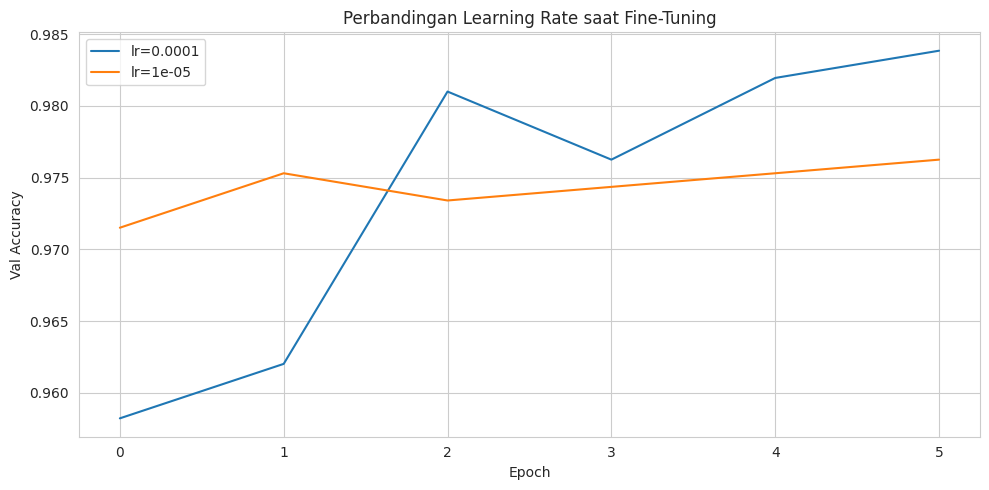

lr=0.0001: best val_accuracy = 0.9839
lr=1e-05: best val_accuracy = 0.9763


In [ ]:
# Bandingkan hasil tuning dua learning rate (1e-4 vs 1e-5) buat lihat mana yang lebih efektif untuk fine-tuning
plt.figure(figsize=(10, 5))
for name, hist in tuning_results.items():
    plt.plot(hist["val_accuracy"], label=name)
plt.title("Perbandingan Learning Rate saat Fine-Tuning")
plt.xlabel("Epoch"); plt.ylabel("Val Accuracy"); plt.legend()
plt.tight_layout()
plt.show()

for name, hist in tuning_results.items():
    print(f"{name}: best val_accuracy = {max(hist['val_accuracy']):.4f}")

Hasilnya `learning_rate=1e-4` memberikan val accuracy terbaik **98,39%** (val loss 0,0762), naik dari 97,63% sebelum fine-tuning — jadi fine-tuning-nya beneran memberi peningkatan (+0,76 poin persentase). Sementara `learning_rate=1e-5` cuma mencapai **97,63%**, persis sama dengan sebelum fine-tuning — artinya LR sekecil itu nyaris tidak memberi update berarti dalam 6 epoch. Model dari `lr=1e-4` inilah yang dipakai sebagai `final_model` untuk evaluasi selanjutnya.


##  9. Evaluasi Model Final

Evaluasi menyeluruh pada **test set** (data yang belum pernah dilihat model sama sekali):
- Accuracy, Precision, Recall, F1-score per kelas
- Confusion Matrix
- Analisis overfitting/underfitting

Evaluasi model final pada **test set** (1.053 gambar) menggunakan classification report — precision, recall, dan f1-score per kelas.


In [ ]:
test_generator.reset()
y_pred_probs = final_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print("~"*60)
print("CLASSIFICATION REPORT")
print("~"*60)
print(classification_report(y_true, y_pred, target_names=class_labels))

33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 317ms/step
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
CLASSIFICATION REPORT
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                     precision    recall  f1-score   support

      Botol_Plastik       0.98      0.97      0.98       216
               Kaca       0.98      0.99      0.98       184
     Karton_Minuman       0.99      1.00      1.00       157
      Kemasan_Logam       0.98      0.96      0.97       182
      Kertas_Karton       0.99      0.99      0.99       157
Sampah_Rumah_Tangga       0.99      1.00      0.99       157

           accuracy                           0.98      1053
          macro avg       0.98      0.99      0.98      1053
       weighted avg       0.98      0.98      0.98      1053



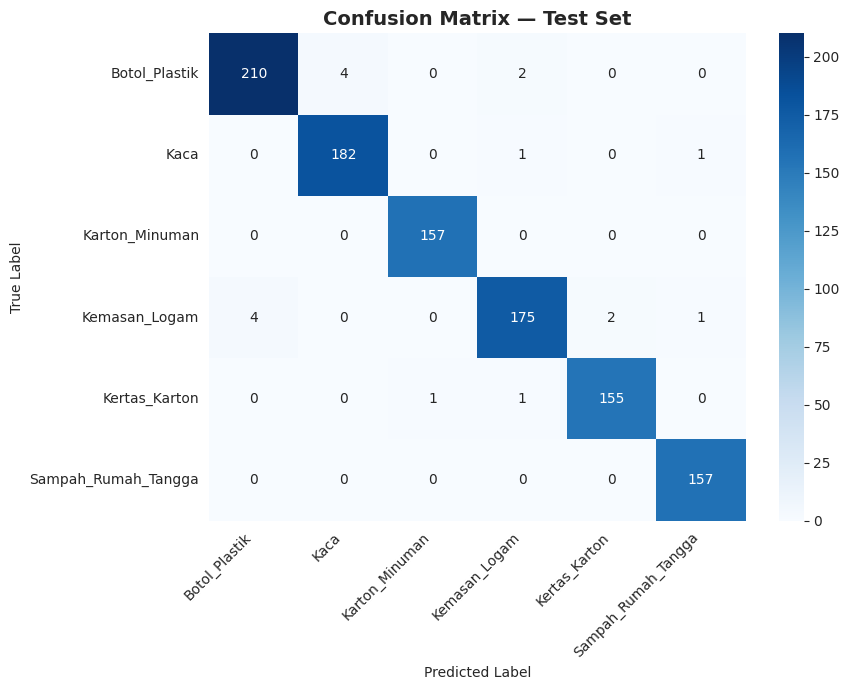


 Kelas paling sering tertukar: 'Botol_Plastik' diprediksi sebagai 'Kaca' sebanyak 4 kali


In [ ]:
# Confusion matrix + cari sel off-diagonal terbesar untuk tahu kelas mana yang paling sering tertukar
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix — Test Set", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
max_confusion_idx = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
print(f"\n Kelas paling sering tertukar: '{class_labels[max_confusion_idx[0]]}' "
      f"diprediksi sebagai '{class_labels[max_confusion_idx[1]]}' "
      f"sebanyak {cm_no_diag[max_confusion_idx]} kali")

Hasil classification report menunjukkan overall accuracy **98%**, dengan f1-score per kelas antara 0,97–1,00. Kelas dengan performa sedikit paling rendah adalah `Kemasan_Logam` (recall 0,96, f1 0,97). Dari confusion matrix, kesalahan paling sering terjadi adalah **`Botol_Plastik` diprediksi sebagai `Kaca`, sebanyak 4 kali** — masuk akal karena botol plastik bening dan kaca sama-sama transparan/mengkilap dan bisa mirip secara visual dalam foto. Tapi perlu digarisbawahi: 4 kesalahan dari total 1.053 gambar test itu sangat sedikit, jadi confusion matrix-nya memang didominasi diagonal (prediksi benar).


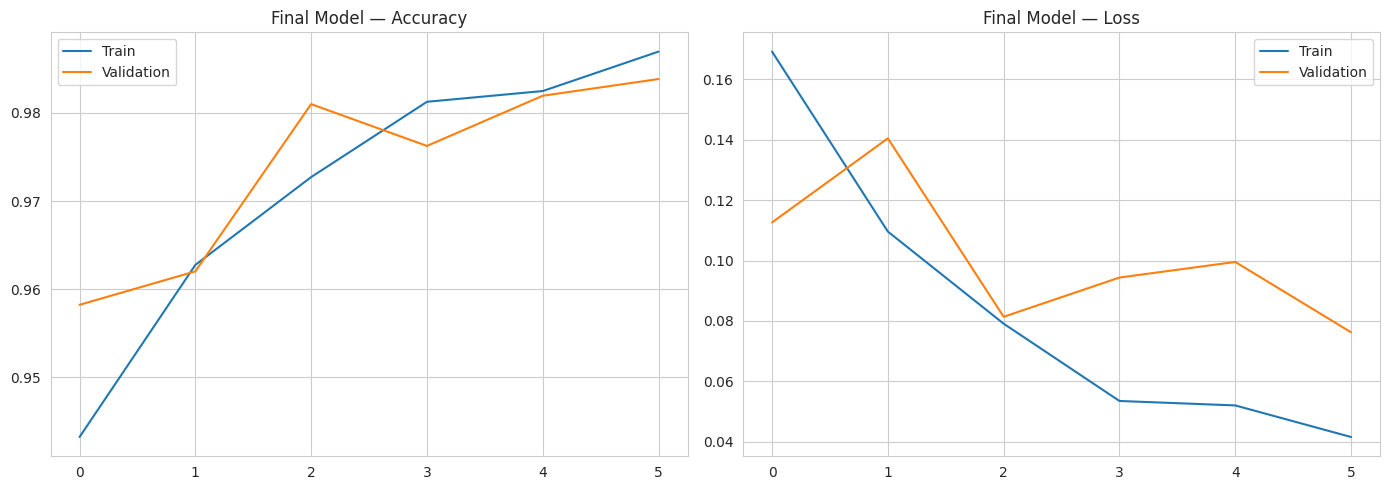

Train accuracy akhir: 0.9870
Val accuracy akhir  : 0.9839
Gap                 : 0.0031
Gap train-val wajar, model cukup general.


In [ ]:
final_history = tuning_results[max(tuning_results, key=lambda k: max(tuning_results[k]["val_accuracy"]))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(final_history["accuracy"], label="Train")
axes[0].plot(final_history["val_accuracy"], label="Validation")
axes[0].set_title("Final Model — Accuracy"); axes[0].legend()

axes[1].plot(final_history["loss"], label="Train")
axes[1].plot(final_history["val_loss"], label="Validation")
axes[1].set_title("Final Model — Loss"); axes[1].legend()
plt.tight_layout()
plt.show()

train_acc_final = final_history["accuracy"][-1]
val_acc_final = final_history["val_accuracy"][-1]
gap = train_acc_final - val_acc_final

print(f"Train accuracy akhir: {train_acc_final:.4f}")
print(f"Val accuracy akhir  : {val_acc_final:.4f}")
print(f"Gap                 : {gap:.4f}")

if gap > 0.15:
    print("Indikasi OVERFITTING, train jauh lebih tinggi dari val.")
elif val_acc_final < 0.6:
    print("Indikasi UNDERFITTING, akurasi masih rendah.")
else:
    print("Gap train-val wajar, model cukup general.")

Hasilnya gap antara train accuracy (98,70%) dan val accuracy (98,39%) sangat kecil (~0,31%), yang berarti model tidak overfitting signifikan dan cukup general — performanya di data yang belum pernah dilihat (val/test) hampir sama bagusnya dengan performa di data training.


In [ ]:
# Uji juga ke folder "test" bawaan dataset (di luar train/val/test hasil split kita) sebagai sanity-check tambahan / cek out-of-distribution
ORIGINAL_TEST_DIR = os.path.join(DATA_ROOT, "1024+", "test")

# Rename folder test ini pakai mapping yang sama, supaya urutan kelas (alfabetis) konsisten dengan urutan kelas saat training - kalau tidak, index kelas bisa tidak nyambung dan prediksi jadi salah kaprah
CLEAN_TEST_DIR = "/content/data_clean_test"
os.makedirs(CLEAN_TEST_DIR, exist_ok=True)

for original_name in os.listdir(ORIGINAL_TEST_DIR):
    src = os.path.join(ORIGINAL_TEST_DIR, original_name)
    if not os.path.isdir(src):
        continue
    clean_name = class_name_mapping.get(original_name, "Sampah_Rumah_Tangga")
    dst = os.path.join(CLEAN_TEST_DIR, clean_name)
    if not os.path.exists(dst):
        os.symlink(src, dst)

orig_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
orig_test_generator = orig_test_datagen.flow_from_directory(
    CLEAN_TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

# Memastikan urutan kelas sama persis dengan training sebelum evaluasi
assert orig_test_generator.class_indices.keys() == train_generator.class_indices.keys() or \
    sorted(orig_test_generator.class_indices) == sorted(train_generator.class_indices), \
    "Urutan/kelas tidak cocok antara test bawaan dan training!"

orig_test_loss, orig_test_acc = final_model.evaluate(orig_test_generator)
print(f"\n Akurasi pada folder 'test' bawaan dataset: {orig_test_acc:.4f}")

Found 157 images belonging to 6 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.7070 - loss: 1.1994

 Akurasi pada folder 'test' bawaan dataset: 0.7070


Akurasi di folder `test` bawaan dataset ternyata jauh lebih rendah, cuma **70,70%**, dibanding test set utama (98%). Ini cukup wajar mengingat: (1) folder ini sangat kecil, cuma 157 gambar total, dengan jumlah per kelas timpang antara 10–44 gambar — makanya satu-dua kesalahan saja sudah bisa menggeser akurasi beberapa persen; dan (2) kemungkinan karakteristik foto di folder ini (sumber, pencahayaan, sudut pengambilan) sedikit berbeda dari data training/test utama, sehingga jadi semacam *out-of-distribution check*. Karena itu, angka 70,70% ini cuma dijadikan referensi tambahan, bukan metrik evaluasi utama — metrik utama tetap 98% dari test set 1.053 gambar di atas.


## 10. Uji Coba Prediksi pada Gambar Baru

Untuk memastikan model bisa dipakai di dunia nyata, coba upload foto sampah sendiri (di luar dataset) dan lihat hasil prediksinya.

Fungsi bantuan untuk memprediksi satu gambar dan menampilkan hasilnya secara visual, lengkap dengan top-3 prediksi (berguna kalau model ragu-ragu antar kelas yang mirip, misalnya kaca vs botol plastik bening).


In [ ]:
# Fungsi bantuan: prediksi satu gambar, tampilkan hasilnya secara visual, plus top-3 prediksi (berguna kalau model ragu antar kelas yang mirip, misal kaca vs botol plastik bening)
def predict_image(img_path, model, class_labels, true_label=None):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0  # samakan dengan preprocessing generator
    img_array = np.expand_dims(img_array, axis=0)

    pred_probs = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(pred_probs)
    pred_label = class_labels[pred_idx]
    confidence = pred_probs[pred_idx] * 100

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    title = f"Prediksi: {pred_label} ({confidence:.1f}%)"
    if true_label:
        is_correct = (true_label == pred_label)
        verdict = "✅ BENAR" if is_correct else "❌ SALAH"
        title += f"\nLabel asli: {true_label} — {verdict}"
    plt.title(title, fontsize=11)
    plt.axis("off")
    plt.show()

    # Menampilkan top-3 prediksi
    top3_idx = np.argsort(pred_probs)[::-1][:3]
    print("Top-3 prediksi:")
    for idx in top3_idx:
        print(f"  {class_labels[idx]:<22s}: {pred_probs[idx]*100:5.2f}%")

    return pred_label, confidence

class_labels = list(train_generator.class_indices.keys())
print("Kelas yang dikenali model:", class_labels)

Kelas yang dikenali model: ['Botol_Plastik', 'Kaca', 'Karton_Minuman', 'Kemasan_Logam', 'Kertas_Karton', 'Sampah_Rumah_Tangga']


In [ ]:
# Upload satu atau beberapa gambar sampah asli (di luar dataset) untuk dites ke model final
print("Upload foto sampah yang mau dites (bisa lebih dari satu file sekaligus):")
uploaded_test_images = files.upload()

Upload foto sampah yang mau dites (bisa lebih dari satu file sekaligus):


Saving Paper_sheet (1).jpg to Paper_sheet (1).jpg



~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Menguji: Paper_sheet (1).jpg
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


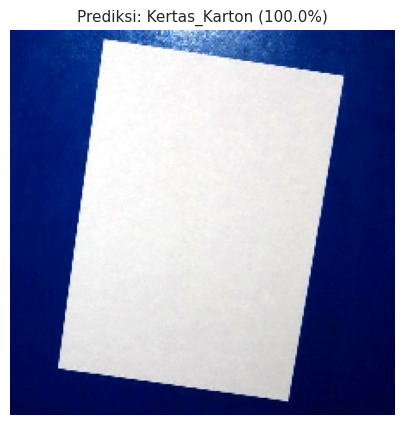

Top-3 prediksi:
  Kertas_Karton         : 100.00%
  Karton_Minuman        :  0.00%
  Kemasan_Logam         :  0.00%


In [ ]:
# Prediksi tiap gambar yang diupload lalu tampilkan hasil top-3-nya
known_labels = {}

for fname in uploaded_test_images.keys():
    print(f"\n{'~'*50}")
    print(f"Menguji: {fname}")
    print(f"{'~'*50}")
    true_label = known_labels.get(fname)
    predict_image(fname, final_model, class_labels, true_label=true_label)

Hasil uji coba pada gambar `Paper_sheet (1).jpg` (foto lembaran kertas yang diupload manual, di luar dataset) diprediksi sebagai `Kertas_Karton` dengan confidence **100,00%**, jauh mengungguli 2 kandidat top-3 lainnya (`Karton_Minuman` dan `Kemasan_Logam`, masing-masing 0,00%). Prediksinya masuk akal untuk gambar lembaran kertas. Tapi perlu dicatat, ini baru 1 gambar percobaan — belum cukup untuk menyimpulkan performa model secara umum di dunia nyata, dan confidence 100% yang sangat ekstrem juga bisa jadi tanda model agak *overconfident* (perlu dites dengan lebih banyak gambar baru dari berbagai kondisi sebelum benar-benar dipakai produksi).


## 11. Simpan Model Untuk Deployment

In [ ]:
# Simpan model final (hasil fine-tuning MobileNetV2, lr=1e-4) untuk tahap deployment, lalu download ke laptop
final_model.save("/content/best_garbage_model.keras")
print("Model final disimpan di /content/best_garbage_model.keras")
print("Download model ke laptop:")

files.download("/content/best_garbage_model.keras")

Model final disimpan di /content/best_garbage_model.keras
Download model ke laptop:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Ringkasan Akhir Proyek

Berdasarkan seluruh proses dan output di atas:

- **Model final:** MobileNetV2 (transfer learning) yang di-fine-tune dengan 20 layer terakhir di-unfreeze dan `learning_rate=1e-4`.
- **Performa di test set (1.053 gambar):** accuracy 98%, weighted f1-score 0,98 — jauh di atas baseline CNN dari nol yang cuma 75,02%.
- **Gap train-val cuma 0,31%**, jadi model tidak overfitting dan generalisasinya bagus.
- **Kesalahan klasifikasi paling umum:** `Botol_Plastik` vs `Kaca` (keduanya sama-sama transparan/mengkilap), tapi jumlahnya kecil (4 dari 1.053 gambar).
- **Sanity check** di folder test bawaan dataset (157 gambar, sangat timpang per kelas) cuma dapat 70,70% — mengingatkan bahwa performa tinggi di atas belum tentu bertahan persis sama di distribusi data lain, dan perlu evaluasi lanjutan dengan data dunia nyata yang lebih banyak.
- **Catatan untuk pengembangan lanjutan:** pemilihan "model terbaik" antara MobileNetV2 dan EfficientNetB0 sebelumnya sempat seri di val accuracy (97,63%), dan dipilih MobileNetV2 lewat tie-breaking implisit dari urutan sorting — bukan karena benar-benar lebih unggul. Ke depannya, ada baiknya tie-breaker eksplisit (misalnya pakai val_loss) atau coba fine-tune EfficientNetB0 juga sebagai pembanding.

Model final disimpan sebagai `best_garbage_model.keras`, siap dipakai untuk tahap deployment.
